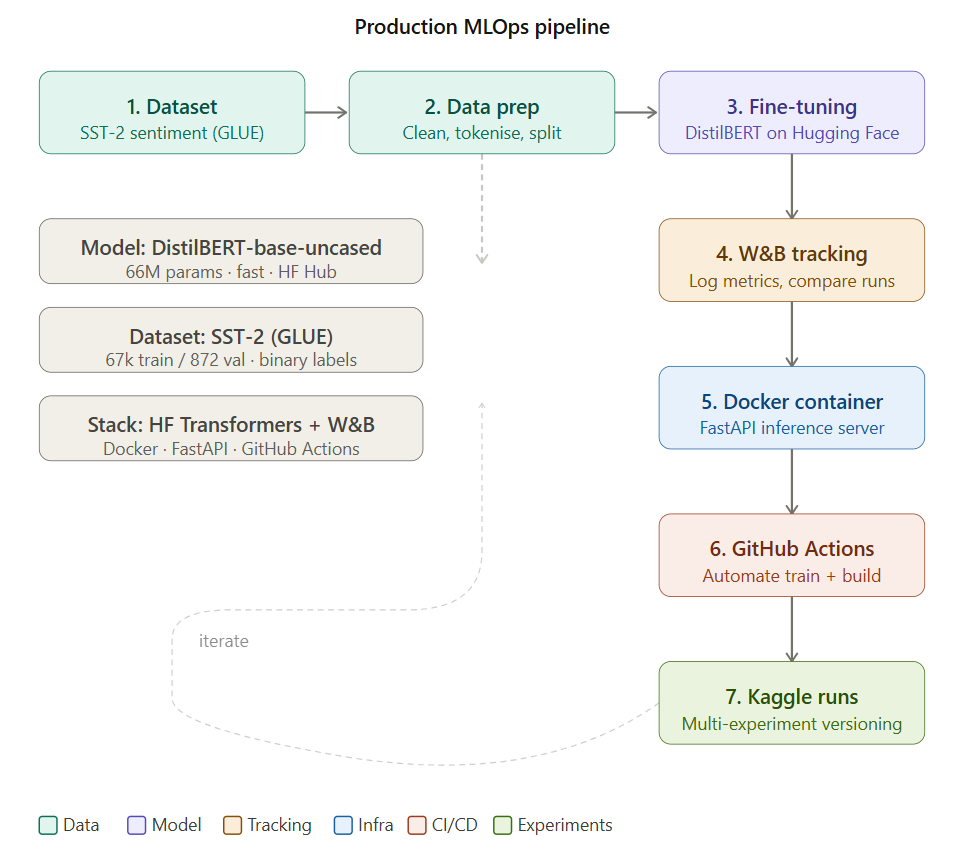

Dataset: SST-2 (Stanford Sentiment Treebank, binary) from the GLUE benchmark — 67k training sentences, 872 validation, two labels (positive/negative). Small enough to fine-tune in under an hour on a free GPU.
Model: distilbert-base-uncased from Hugging Face — 66M parameters, 40% smaller than BERT-base, retains 97% of BERT's accuracy. Perfect for a teaching pipeline.
Task: Sentence-level sentiment classification.

In [4]:
import torch
import transformers
import datasets
import wandb
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("wandb:", wandb.__version__)

torch: 2.10.0+cu128
transformers: 5.0.0
datasets: 4.8.5
wandb: 0.25.1


In [5]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [6]:
# ── CELL 2 ── Load secrets (Kaggle Secrets — never hard-code tokens) ──────────
from kaggle_secrets import UserSecretsClient
import os
import wandb
from huggingface_hub import login

secrets = UserSecretsClient()

os.environ["WANDB_API_KEY"] = secrets.get_secret("WANDB_API_KEY")
HF_TOKEN = secrets.get_secret("HF_TOKEN")

login(token=HF_TOKEN)   # authenticate with Hugging Face Hub
wandb.login()           # authenticate with W&B (uses env var set above)

print("Secrets loaded ✓")


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: g25ait2096 (g25ait2096-iitj) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Secrets loaded ✓


In [7]:
import wandb

run = wandb.init(
    project="test-project",
    name="test-run"
)

wandb.log({"accuracy": 0.95})
run.finish()

accuracy,▁
accuracy,0.95


In [8]:
# ── CELL 3 ── Imports ─────────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset, DatasetDict, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import accuracy_score, f1_score

In [9]:


# ── CELL 4 ── Configuration — edit this block to create Version 2 ─────────────
# ============================================================
#  VERSION  |  epochs  |  lr      |  batch  |  run_name
# ----------|----------|----------|---------|------------
#    v1     |    3     |  3e-5    |   16    |  run-v1
#    v2     |    5     |  2e-5    |   32    |  run-v2   ← change these
# ============================================================

VERSION      = "v1"         # <-- change to "v2" for the second run
MODEL_NAME   = "distilbert-base-uncased"
NUM_EPOCHS   = 3            # v2: change to 5
BATCH_SIZE   = 16           # v2: change to 32
LEARNING_RATE = 3e-5        # v2: change to 2e-5
TRAIN_SIZE   = 10_000
VAL_SIZE     = 1_000
SEED         = 42



In [10]:
# ── CELL 5 ── Prepare dataset ─────────────────────────────────────────────────
import re

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^\x20-\x7E]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

raw = load_dataset("stanfordnlp/sst2")

def prep_split(split_name, size):
    df = raw[split_name].to_pandas()
    df["sentence"] = df["sentence"].map(clean_text)
    df = df[df["sentence"].str.len() > 0].drop_duplicates("sentence")
    df = df.sample(n=min(size, len(df)), random_state=SEED).reset_index(drop=True)
    return Dataset.from_pandas(df[["sentence", "label"]])

train_ds = prep_split("train",      TRAIN_SIZE)
val_ds   = prep_split("validation", VAL_SIZE)

id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

with open("id2label.json", "w") as f:
    json.dump(id2label, f, indent=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train: 10000 | Val: 872


In [11]:
# ── CELL 6 ── Tokenise ────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenise(batch):
    return tokenizer(batch["sentence"], truncation=True, max_length=128)

train_tok = train_ds.map(tokenise, batched=True)
val_tok   = val_ds.map(tokenise,   batched=True)

collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Tokenisation done ✓")



config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Tokenisation done ✓


In [12]:
# ── CELL 7 ── Load model ──────────────────────────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 66,955,010


In [13]:
# ── CELL 8 ── W&B run init ────────────────────────────────────────────────────
wandb.init(
    project="mlops-assignment3",
    name=f"run-{VERSION}",
    config={
        "model":         MODEL_NAME,
        "epochs":        NUM_EPOCHS,
        "batch_size":    BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "version":       VERSION,
        "platform":      "Kaggle",
        "train_size":    TRAIN_SIZE,
        "val_size":      VAL_SIZE,
    },
)
print(f"W&B run '{VERSION}' initialised ✓")

W&B run 'v1' initialised ✓


In [14]:
# ── CELL 9 ── Metrics function ────────────────────────────────────────────────
def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="weighted"),
    }

In [15]:
# ── CELL 10 ── Training arguments ─────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = f"./results-{VERSION}",
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = 64,
    learning_rate               = LEARNING_RATE,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    report_to                   = "wandb",
    run_name                    = f"run-{VERSION}",
    seed                        = SEED,
    fp16                        = True,           # use Kaggle T4 half-precision
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [16]:
# ── CELL 11 ── Train ──────────────────────────────────────────────────────────
trainer = Trainer(
    model             = model,
    args              = training_args,
    train_dataset     = train_tok,
    eval_dataset      = val_tok,
    processing_class  = tokenizer,
    data_collator     = collator,
    compute_metrics   = compute_metrics,
)



In [17]:
# ── CELL 12 ── Evaluate & log final metrics ───────────────────────────────────
results = trainer.evaluate()
print("Final eval results:", results)

wandb.run.summary.update({
    "final_accuracy": results["eval_accuracy"],
    "final_f1":       results["eval_f1"],
    "final_loss":     results["eval_loss"],
})


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Final eval results: {'eval_loss': 1.3939684629440308, 'eval_accuracy': 0.4908256880733945, 'eval_f1': 0.32318983768525056, 'eval_runtime': 2.0064, 'eval_samples_per_second': 434.614, 'eval_steps_per_second': 3.489}


In [18]:
print("Training logs:", trainer.state.log_history)

Training logs: [{'eval_loss': 1.3939684629440308, 'eval_accuracy': 0.4908256880733945, 'eval_f1': 0.32318983768525056, 'eval_runtime': 2.0064, 'eval_samples_per_second': 434.614, 'eval_steps_per_second': 3.489, 'step': 0}]


In [19]:
# ── CELL 13 ── Push model to Hugging Face Hub (Task 5) ────────────────────────
HF_REPO = f"g25ait2096/distilbert-sst2-{VERSION}"   # ← replace username

model.push_to_hub(HF_REPO)
tokenizer.push_to_hub(HF_REPO)
print(f"Model pushed to: https://huggingface.co/{HF_REPO}")

# Log model URL to W&B run summary
wandb.run.summary["huggingface_model"] = f"https://huggingface.co/{HF_REPO}"

wandb.finish()
print("W&B run finished ✓")

README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Model pushed to: https://huggingface.co/g25ait2096/distilbert-sst2-v1


eval/accuracy,▁
eval/f1,▁
eval/loss,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
train/global_step,▁
eval/accuracy,0.49083
eval/f1,0.32319
eval/loss,1.39397
eval/runtime,2.0064


W&B run finished ✓


In [20]:
print("Train dataset size:", len(train_tok))
print("Val dataset size:", len(val_tok))
print("Train columns:", train_tok.column_names)
print("Sample row:", train_tok[0])

Train dataset size: 10000
Val dataset size: 872
Train columns: ['sentence', 'label', 'input_ids', 'token_type_ids', 'attention_mask']
Sample row: {'sentence': 'mr. day-lewis roars with leonine power', 'label': 1, 'input_ids': [101, 2720, 1012, 2154, 1011, 4572, 11950, 2015, 2007, 6506, 3170, 2373, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [21]:
print("Per device batch size:", training_args.per_device_train_batch_size)
print("Num epochs:", training_args.num_train_epochs)
print("Max steps:", training_args.max_steps)
print("Training dataset length:", len(trainer.train_dataset))

Per device batch size: 16
Num epochs: 3
Max steps: -1
Training dataset length: 10000


In [22]:
# Rename label → labels in both datasets
train_tok = train_tok.rename_column("label", "labels")
val_tok   = val_tok.rename_column("label", "labels")

# Remove sentence column
train_tok = train_tok.remove_columns(["sentence"])
val_tok   = val_tok.remove_columns(["sentence"])

# Set format to PyTorch tensors
train_tok.set_format("torch")
val_tok.set_format("torch")

print("Train columns:", train_tok.column_names)
print("Val columns:", val_tok.column_names)

Train columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Val columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [23]:
# Re-create Trainer with fixed dataset
trainer = Trainer(
    model             = model,
    args              = training_args,
    train_dataset     = train_tok,
    eval_dataset      = val_tok,
    processing_class  = tokenizer,
    data_collator     = collator,
    compute_metrics   = compute_metrics,
)
print("Trainer ready ✓")

Trainer ready ✓


In [25]:
# Train
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.767936,0.888761,0.888767
2,0.305133,0.761815,0.893349,0.893255
3,0.305133,1.020914,0.895642,0.895644


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=939, training_loss=0.23026070477990424, metrics={'train_runtime': 119.4097, 'train_samples_per_second': 251.236, 'train_steps_per_second': 7.864, 'total_flos': 310793354884224.0, 'train_loss': 0.23026070477990424, 'epoch': 3.0})

In [26]:
# Evaluate
results = trainer.evaluate()
print("Final eval results:", results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Final eval results: {'eval_loss': 1.0209144353866577, 'eval_accuracy': 0.8956422018348624, 'eval_f1': 0.8956442610974278, 'eval_runtime': 0.907, 'eval_samples_per_second': 961.443, 'eval_steps_per_second': 7.718, 'epoch': 3.0}


In [27]:
HF_REPO = "g25ait2096/distilbert-sst2-v1"

model.push_to_hub(HF_REPO)
tokenizer.push_to_hub(HF_REPO)
print(f"Model pushed to: https://huggingface.co/{HF_REPO}")
print("Done ✓")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Model pushed to: https://huggingface.co/g25ait2096/distilbert-sst2-v1
Done ✓
